In [ ]:
%load_ext autoreload
%autoreload 1
%aimport rectificacion, aruco

import os,shutil, glob, cv2 as cv
import pickle
import open3d as o3d, numpy as np
import plotly.graph_objects as go

DATA_DIR = "data"
CAPT_DIR = "data/captures"
RECT_DIR = "data/rectified"
TUNER_OUT = "data/pointcloud/tuner"
WORLD_OUT = "data/pointcloud/world_pnp"
os.makedirs(TUNER_OUT, exist_ok=True)
os.makedirs(WORLD_OUT, exist_ok=True)

with open(os.path.join(DATA_DIR, "stereo_maps.pkl"), "rb") as f:
    maps = pickle.load(f)
Q      = np.array(maps["Q"], dtype=np.float32)
P1     = np.array(maps.get("P1", maps.get("left_P")), dtype=np.float32)
K_rect = P1[:3, :3]

print("K_rect:\n", K_rect)
print("Q[3,2]=", float(Q[3,2]))



K_rect:
 [[604.2844    0.      966.26373]
 [  0.      604.2844  524.7561 ]
 [  0.        0.        1.     ]]
Q[3,2]= 16.66666603088379


# LIMPIEZA: Borrar nubes antiguas (GRIS) para regenerar con COLOR

In [ ]:

dirs_to_clean = {
    "data/pointcloud": "*.ply",           
    "data/pointcloud/world_pnp": "*.ply", 
}

print("=== LIMPIEZA DE ARCHIVOS ANTIGUOS ===\n")

for dir_path, pattern in dirs_to_clean.items():
    if not os.path.exists(dir_path):
        print(f"⚠️  {dir_path} no existe, salteando...")
        continue
    
    files = glob.glob(os.path.join(dir_path, pattern))
    
    if len(files) == 0:
        print(f"✓ {dir_path} ya está vacío")
    else:
        print(f"🗑️  Borrando {len(files)} archivos en {dir_path}/")
        for f in files:
            try:
                os.remove(f)
                print(f"   ✓ {os.path.basename(f)}")
            except Exception as e:
                print(f"   ✗ Error borrando {os.path.basename(f)}: {e}")
        print(f"   → Borrados {len(files)} archivos\n")

merged = "data/pointcloud/final_merged.ply"
if os.path.exists(merged):
    os.remove(merged)
    print(f"🗑️  Borrado: {merged}")


=== LIMPIEZA DE ARCHIVOS ANTIGUOS ===

🗑️  Borrando 3 archivos en data/pointcloud/
   ✓ final_merged.ply
   ✓ final_merged_cropped.ply
   ✓ buda_mesh_poisson.ply
   → Borrados 3 archivos

🗑️  Borrando 21 archivos en data/pointcloud/world_pnp/
   ✓ 007_left_14_rect_world.ply
   ✓ 002_left_1_rect_world.ply
   ✓ 004_left_11_rect_world.ply
   ✓ 009_left_16_rect_world.ply
   ✓ 016_left_4_rect_world.ply
   ✓ 005_left_12_rect_world.ply
   ✓ 008_left_15_rect_world.ply
   ✓ 006_left_13_rect_world.ply
   ✓ 003_left_10_rect_world.ply
   ✓ 018_left_6_rect_world.ply
   ✓ 014_left_20_rect_world.ply
   ✓ 020_left_8_rect_world.ply
   ✓ 011_left_18_rect_world.ply
   ✓ 013_left_2_rect_world.ply
   ✓ 012_left_19_rect_world.ply
   ✓ 001_left_0_rect_world.ply
   ✓ 017_left_5_rect_world.ply
   ✓ 015_left_3_rect_world.ply
   ✓ 021_left_9_rect_world.ply
   ✓ 019_left_7_rect_world.ply
   ✓ 010_left_17_rect_world.ply
   → Borrados 21 archivos


✅ Limpieza completa. Ahora regenerá las nubes:
   1. profundidad.ca

# RECTIFICACION

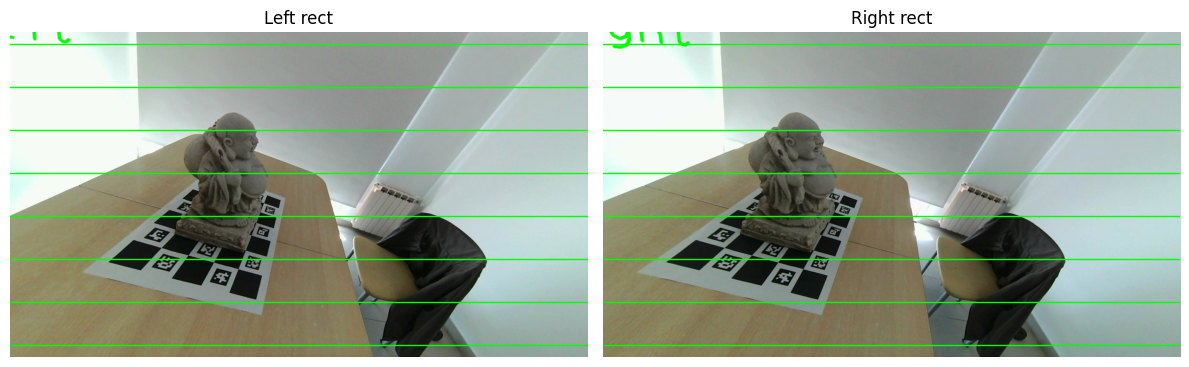

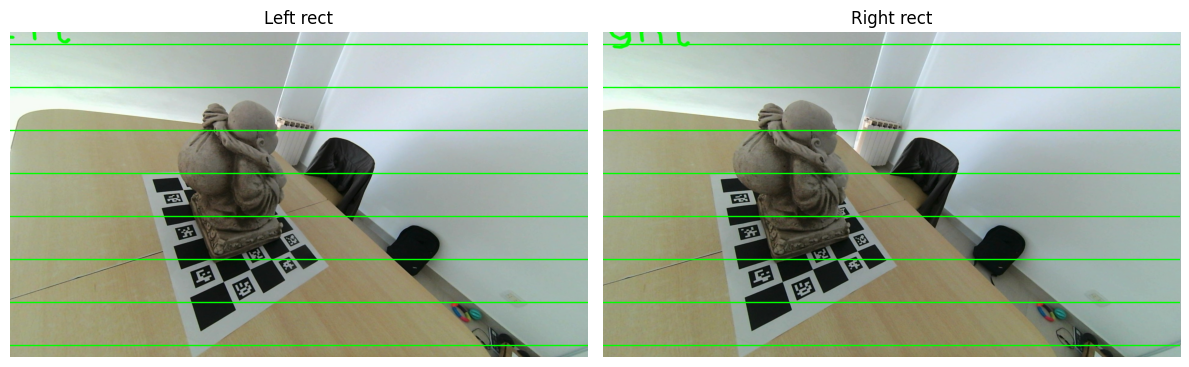

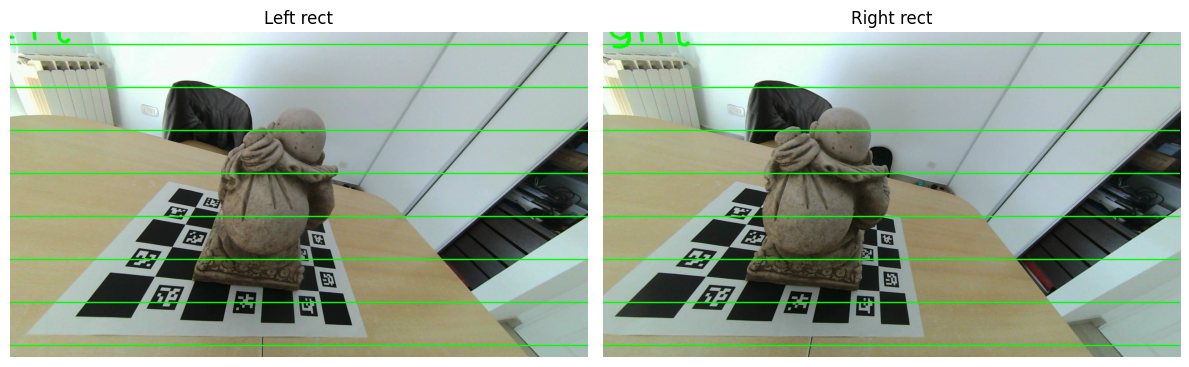

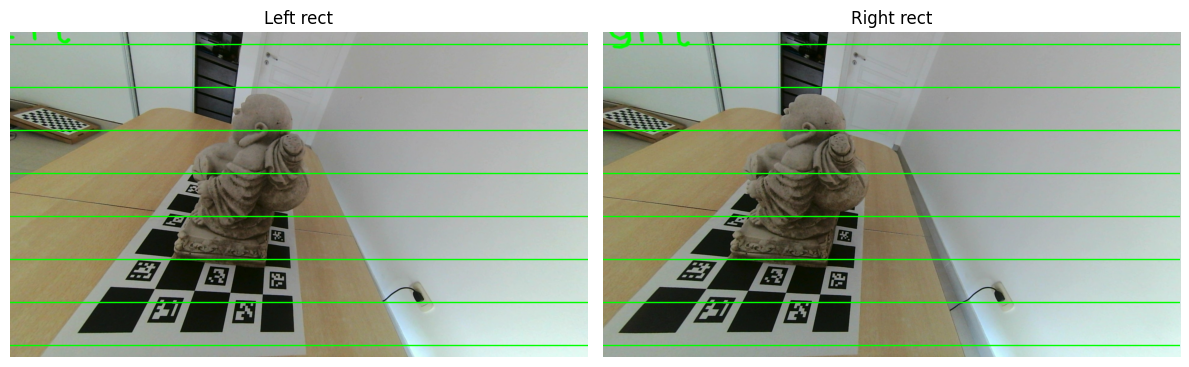

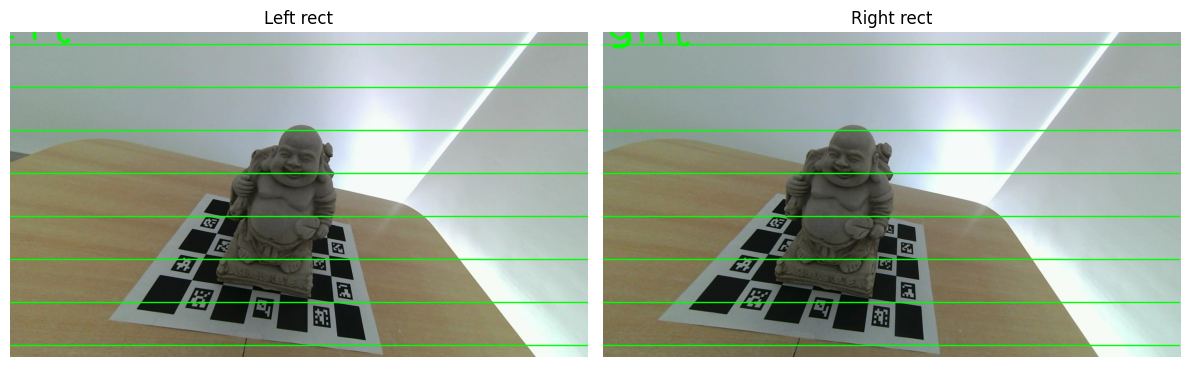

In [ ]:
import importlib, rectificacion
importlib.reload(rectificacion)

Q_from_rect, pares = rectificacion.rectificar_imagenes(
    data_dir=DATA_DIR,
    captures_dir=CAPT_DIR,
    out_dir=RECT_DIR,
    visualizar=True,
    n_muestras=5,
    n_lineas=8
)



# TUNER

In [ ]:
WIN = "Tuner"
cv.namedWindow(WIN, cv.WINDOW_NORMAL)
cv.resizeWindow(WIN, 900, 650)
cv.moveWindow(WIN, 100, 60)

def show_disparity(disp):
    """
    Normaliza y visualiza el mapa de disparidad con un colormap.
    
    Parámetros:
        disp (np.ndarray): Mapa de disparidad (valores de disparidad en píxeles).
    
    Retorna:
        np.ndarray: Imagen de disparidad coloreada (BGR) para visualización.
    """
    disp_vis = cv.normalize(disp, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    disp_vis = cv.applyColorMap(disp_vis, cv.COLORMAP_TURBO)
    cv.imshow(WIN, disp_vis)
    return disp_vis

def nothing(_): pass
cv.createTrackbar("numDisp(x16)", WIN, 12, 64, nothing)
cv.createTrackbar("blockSize",    WIN, 7,  31, nothing)
cv.createTrackbar("preFilterCap", WIN, 31, 63, nothing)
cv.createTrackbar("uniqueness",   WIN, 10, 50, nothing)
cv.createTrackbar("speckleWinSz", WIN, 50, 200, nothing)
cv.createTrackbar("speckleRange", WIN, 32, 64,  nothing)
cv.createTrackbar("disp12MaxDiff",WIN, 1,  25,  nothing)
cv.createTrackbar("zMin(cm)",     WIN, 10, 500, nothing)
cv.createTrackbar("zMax(cm)",     WIN, 120, 1000, nothing)



In [ ]:
lefts  = sorted(glob.glob(os.path.join(RECT_DIR, "*left*_rect.png")))
rights = [p.replace("left", "right") for p in lefts]
pairs  = [(l, r) for l, r in zip(lefts, rights) if os.path.exists(r)]

print(f"Pares detectados: {len(pairs)}")
if not pairs:
    raise SystemExit("No se encontraron pares rectificados.")

idx = 0
while idx < len(pairs):
    Lp, Rp = pairs[idx]
    base   = os.path.splitext(os.path.basename(Lp))[0]
    print(f"\n→ {base}")

    L = cv.imread(Lp, cv.IMREAD_GRAYSCALE)
    R = cv.imread(Rp, cv.IMREAD_GRAYSCALE)
    if L is None or R is None:
        print("  ⚠️ No se pudo leer el par, saltando…")
        idx += 1
        continue

    while True:
        nd_mult16   = cv.getTrackbarPos("numDisp(x16)", WIN)
        numDisp     = max(1, nd_mult16) * 16
        bs          = cv.getTrackbarPos("blockSize", WIN)
        blockSize   = bs if bs % 2 == 1 else bs + 1
        preCap      = max(1, cv.getTrackbarPos("preFilterCap", WIN))
        uniq        = cv.getTrackbarPos("uniqueness", WIN)
        speckWin    = cv.getTrackbarPos("speckleWinSz", WIN)
        speckRange  = cv.getTrackbarPos("speckleRange", WIN)
        d12         = cv.getTrackbarPos("disp12MaxDiff", WIN)
        zmin_cm     = cv.getTrackbarPos("zMin(cm)", WIN)
        zmax_cm     = cv.getTrackbarPos("zMax(cm)", WIN)
        zmin, zmax  = zmin_cm/100.0, zmax_cm/100.0

        stereo = cv.StereoSGBM_create(
            minDisparity=0,
            numDisparities=numDisp,
            blockSize=blockSize,
            P1=8*1*blockSize*blockSize,
            P2=32*1*blockSize*blockSize,
            disp12MaxDiff=d12,
            preFilterCap=preCap,
            uniquenessRatio=uniq,
            speckleWindowSize=speckWin,
            speckleRange=speckRange,
            mode=cv.STEREO_SGBM_MODE_SGBM_3WAY
        )

        disp16 = stereo.compute(L, R).astype(np.int16)
        disp   = disp16.astype(np.float32) / 16.0
        disp_vis = show_disparity(disp)

        key = cv.waitKey(30) & 0xFF
        if key == 27:
            cv.destroyAllWindows(); raise SystemExit
        elif key == ord('n'):
            idx += 1; break
        elif key == ord('s'):
            cv.imwrite(os.path.join(TUNER_OUT, f"{base}_disp.png"), disp_vis)
            pts3d = cv.reprojectImageTo3D(disp, Q, handleMissingValues=True)
            mask = (disp > 0)
            Z = pts3d[...,2]
            mask &= (Z > zmin) & (Z < zmax)
            pts = pts3d[mask].reshape(-1,3)
            cols = cv.cvtColor(L, cv.COLOR_GRAY2BGR)[mask].reshape(-1,3) / 255.0
            if len(pts)==0:
                print("  ⚠️ nube vacía con estos parámetros."); continue
            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64))
            pcd.colors = o3d.utility.Vector3dVector(cols.astype(np.float64))
            out_ply = os.path.join(TUNER_OUT, f"{base}_world.ply")
            o3d.io.write_point_cloud(out_ply, pcd, write_ascii=False)
            print(f"  💾 guardado: {base}")
            try:
                o3d.visualization.draw_geometries([pcd], window_name=f"Nube: {base}", width=1200, height=800)
            except Exception:
                try:
                    import plotly.graph_objects as go
                    pts_np = np.asarray(pcd.points)
                    idx = np.linspace(0, len(pts_np)-1, min(len(pts_np), 200_000)).astype(int)
                    xyz = pts_np[idx]
                    fig = go.Figure([go.Scatter3d(x=xyz[:,0], y=xyz[:,1], z=xyz[:,2], mode="markers",
                                                  marker=dict(size=1))])
                    fig.update_layout(scene=dict(aspectmode="data"), width=1200, height=800, title=f"Nube: {base}")
                    fig.show()
                    print("  (Viewer nativo no disponible; usando visor web)")
                except Exception:
                    print(f"  ⚠️ No pude abrir visor; abrí el PLY: {out_ply}")

print("\n✅ Listo. N: siguiente | S: guardar | ESC: salir")



Pares detectados: 21

→ 001_left_0_rect


  💾 guardado: 001_left_0_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
  💾 guardado: 001_left_0_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display

→ 002_left_1_rect
  💾 guardado: 002_left_1_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display

→ 003_left_10_rect
  💾 guardado: 003_left_10_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display

→ 004_left_11_rect
  💾 guardado: 004_left_11_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
  💾 guardado: 004_left_11_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
  💾 guardado: 004_left_11_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display

→ 005_left_12_rect
  💾 guardado: 005_left_12_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display

→ 006_left_13_rect
  💾 guardado: 006_left_13_rect
[Open3D WARNING] 

# UNA NUBE

In [ ]:
import numpy as np
one = sorted(glob.glob(os.path.join(TUNER_OUT, "*_world.ply")))
assert one, "No hay nubes en TUNER_OUT; corré el tuner y guardá alguna."
pcd = o3d.io.read_point_cloud(one[0])
pts = np.asarray(pcd.points)
print(f"N puntos: {len(pts)} | Z: [{pts[:,2].min():.3f}, {pts[:,2].max():.3f}]")
try:
    o3d.visualization.draw_geometries([pcd], window_name="Una nube", width=1200, height=800)
except Exception as e:
    print("Viewer no disponible:", e)



N puntos: 225765 | Z: [0.190, 0.390]
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display


# POSE CON CHARUCO (del Archivo2)

In [ ]:
import cv2
import aruco

use_dict = cv2.aruco.DICT_6X6_250
squares_x = 5
squares_y = 7
square_length_mm = 52.6     
marker_length_mm = 31.3    

square_length = square_length_mm / 1000.0  
marker_length = marker_length_mm / 1000.0  

board = aruco.create_charuco_board(
    squares_x,
    squares_y,
    square_length,
    marker_length,
    use_dict
)

print(f"✅ Board Charuco creado: {squares_x}x{squares_y}")
print(f"   Cuadrado: {square_length_mm}mm = {square_length}m")
print(f"   Marker: {marker_length_mm}mm = {marker_length}m")


✅ Board Charuco creado: 5x7
   Cuadrado: 52.6mm = 0.0526m
   Marker: 31.3mm = 0.0313m


# Función para detectar pose con Charuco (adaptada de Archivo2)

In [ ]:
import cv2, numpy as np
import aruco

dist0 = np.zeros((1,5), dtype=np.float64)

def pose_cam_to_world_charuco(img_path, K_rect, dist0, board):
    """
    Detecta Charuco y estima pose, devuelve T_cam->world.
    Usa el mismo método que Archivo2: detect_charuco_markers + estimate_camera_pose_with_homography
    """
    img = cv2.imread(img_path)
    if img is None:
        return None
    
    detection = aruco.detect_charuco_markers(img, board)
    
    calibration = (K_rect, dist0)
    pose = aruco.estimate_camera_pose_with_homography(
        img, board, detection, calibration
    )
    
    if pose is None:
        return None
    
    ok, rvec, tvec = pose
    if not ok:
        return None
    
    R, _ = cv2.Rodrigues(np.asarray(rvec, np.float64).reshape(3,1))
    t = np.asarray(tvec, np.float64).reshape(3,1)
    
    T_cw = np.eye(4, dtype=np.float64)
    T_cw[:3, :3] = R.T
    T_cw[:3, 3] = (-R.T @ t).ravel()
    
    return T_cw

print("✅ Función pose_cam_to_world_charuco lista")

✅ Función pose_cam_to_world_charuco lista


# Transformar cada nube con su pose Charuco → guardar en world_pnp

In [ ]:
import os, glob
import open3d as o3d
import numpy as np

RECT_DIR  = "data/rectified"
RAW_DIR   = "data/pointcloud/tuner"      
WORLD_DIR = "data/pointcloud/world_pnp"  
os.makedirs(WORLD_DIR, exist_ok=True)

left_paths = sorted(glob.glob(os.path.join(RECT_DIR, "*left*_rect.png")))
ok = miss = fail_pose = 0

print(f"🔄 Procesando {len(left_paths)} imágenes...\n")

for lp in left_paths:
    base = os.path.splitext(os.path.basename(lp))[0]
    
    # 1) Estimar pose con Charuco
    T_cw = pose_cam_to_world_charuco(lp, K_rect, dist0, board)
    if T_cw is None:
        print(f"[X] Pose fallida (Charuco no detectado): {base}")
        fail_pose += 1
        continue
    
    # 2) Buscar nube correspondiente
    cand1 = os.path.join(RAW_DIR, f"{base}.ply")
    cand2 = os.path.join(RAW_DIR, f"{base}_world.ply")
    ply_in = cand1 if os.path.exists(cand1) else (cand2 if os.path.exists(cand2) else None)
    
    if ply_in is None:
        print(f"[X] Falta nube: {base}")
        miss += 1
        continue
    
    pcd = o3d.io.read_point_cloud(ply_in)
    if len(pcd.points) == 0:
        print(f"[!] Nube vacía: {base}")
        continue
    
    pcd_world = pcd.transform(T_cw.copy())
    
    outp = os.path.join(WORLD_DIR, f"{base}_world.ply")
    o3d.io.write_point_cloud(outp, pcd_world, write_ascii=False)
    ok += 1
    print(f"✅ {base}")

print(f"\n📊 RESUMEN:")
print(f"   Transformadas: {ok}")
print(f"   Pose fallida: {fail_pose}")
print(f"   Nube faltante: {miss}")


🔄 Procesando 21 imágenes...

✅ 001_left_0_rect
✅ 002_left_1_rect
✅ 003_left_10_rect
✅ 004_left_11_rect
✅ 005_left_12_rect
✅ 006_left_13_rect
✅ 007_left_14_rect
✅ 008_left_15_rect
✅ 009_left_16_rect
✅ 010_left_17_rect
✅ 011_left_18_rect
✅ 012_left_19_rect
✅ 013_left_2_rect
✅ 014_left_20_rect
✅ 015_left_3_rect
✅ 016_left_4_rect
✅ 017_left_5_rect
✅ 018_left_6_rect
✅ 019_left_7_rect
✅ 020_left_8_rect
✅ 021_left_9_rect

📊 RESUMEN:
   Transformadas: 21
   Pose fallida: 0
   Nube faltante: 0


# ICP suave para alinear

In [10]:
import numpy as np, open3d as o3d, glob, os

WORLD_DIR = "data/pointcloud/world_pnp"
paths = sorted(glob.glob(os.path.join(WORLD_DIR, "*_world.ply")))
if len(paths) >= 2:
    ref = o3d.io.read_point_cloud(paths[0]).voxel_down_sample(0.01)
    ref.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.03, max_nn=30))
    for p in paths[1:]:
        mov = o3d.io.read_point_cloud(p).voxel_down_sample(0.01)
        mov.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.03, max_nn=30))
        reg = o3d.pipelines.registration.registration_icp(
            mov, ref, 0.03, np.eye(4),
            o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=50)
        )
        full = o3d.io.read_point_cloud(p)
        full.transform(reg.transformation)
        o3d.io.write_point_cloud(p, full, write_ascii=False)
        print("ICP ok:", os.path.basename(p))
else:
    print("No hay suficientes nubes para ICP (≥2).")


ICP ok: 002_left_1_rect_world.ply
ICP ok: 003_left_10_rect_world.ply
ICP ok: 004_left_11_rect_world.ply
ICP ok: 005_left_12_rect_world.ply
ICP ok: 006_left_13_rect_world.ply
ICP ok: 007_left_14_rect_world.ply
ICP ok: 008_left_15_rect_world.ply
ICP ok: 009_left_16_rect_world.ply
ICP ok: 010_left_17_rect_world.ply
ICP ok: 011_left_18_rect_world.ply
ICP ok: 012_left_19_rect_world.ply
ICP ok: 013_left_2_rect_world.ply
ICP ok: 014_left_20_rect_world.ply
ICP ok: 015_left_3_rect_world.ply
ICP ok: 016_left_4_rect_world.ply
ICP ok: 017_left_5_rect_world.ply
ICP ok: 018_left_6_rect_world.ply
ICP ok: 019_left_7_rect_world.ply
ICP ok: 020_left_8_rect_world.ply
ICP ok: 021_left_9_rect_world.ply


# MERGE

In [ ]:
import open3d as o3d, glob, os, numpy as np

WORLD_DIR = "data/pointcloud/world_pnp"
OUT_DIR   = "data/pointcloud"
os.makedirs(OUT_DIR, exist_ok=True)

plys = sorted(glob.glob(os.path.join(WORLD_DIR, "*_world.ply")))
assert plys, "No hay nubes transformadas."

print(f"🔄 Fusionando {len(plys)} nubes...")

merged = o3d.geometry.PointCloud()
for p in plys:
    merged += o3d.io.read_point_cloud(p)
print(f"   Total bruto: {len(merged.points)} puntos")

merged_down = merged.voxel_down_sample(0.005)  # 5mm (era 8mm)
print(f"   Después de voxel(5mm): {len(merged_down.points)} puntos")

merged_clean, inliers = merged_down.remove_statistical_outlier(
    nb_neighbors=20,    
    std_ratio=2.5       
)
print(f"   Después de outlier filter: {len(merged_clean.points)} puntos")

T_flip = np.array([
    [1,  0,  0, 0],
    [0,  1,  0, 0],
    [0,  0, -1, 0],  
    [0,  0,  0, 1]
], dtype=np.float64)


merged_clean.transform(T_flip)

out_path = os.path.join(OUT_DIR, "final_merged.ply")
o3d.io.write_point_cloud(out_path, merged_clean, write_ascii=False)
print(f"\n✅ Guardado: {out_path}")
print(f"   Puntos finales: {len(merged_clean.points)}")


🔄 Fusionando 21 nubes...
   Total bruto: 4719855 puntos
   Después de voxel(5mm): 83027 puntos
   Después de outlier filter: 81065 puntos

✅ Guardado: data/pointcloud/final_merged.ply
   Puntos finales: 81065


# RECORTAR con bounding box (eliminar ruido de los bordes)


In [ ]:
import open3d as o3d, numpy as np
import plotly.graph_objects as go

# PASO 1: Cargar merged completo
merged = o3d.io.read_point_cloud("data/pointcloud/final_merged.ply")
pts = np.asarray(merged.points)
print(f"📊 Puntos antes: {len(pts)}")

# PASO 2: Recortar con bbox (🔧 ajustá estos valores)
bbox_min = np.array([-0.082, -0.046, 0.04])  # 📊 Valores del diagnóstico
bbox_max = np.array([0.336,  0.423,  0.3])   # 📊 Valores del diagnóstico
bbox = o3d.geometry.AxisAlignedBoundingBox(min_bound=bbox_min, max_bound=bbox_max)
merged_cropped = merged.crop(bbox)
print(f"✂️  Después: {len(merged_cropped.points)} puntos")

# PASO 3: Guardar
o3d.io.write_point_cloud("data/pointcloud/final_merged_cropped.ply", merged_cropped, write_ascii=False)
print(f"💾 Guardado: final_merged_cropped.ply")

# PASO 4: Visualizar en navegador
pts_crop = np.asarray(merged_cropped.points)
cols = np.asarray(merged_cropped.colors) if merged_cropped.has_colors() else None

if len(pts_crop) > 200000:
    idx = np.random.choice(len(pts_crop), 200000, replace=False)
    pts_sample, cols_sample = pts_crop[idx], (cols[idx] if cols is not None else None)
else:
    pts_sample, cols_sample = pts_crop, cols

if cols_sample is None:
    marker_dict = dict(size=2, color=pts_sample[:,2], colorscale="Viridis", showscale=True)
else:
    rgb_strings = [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r,g,b in cols_sample]
    marker_dict = dict(size=2, color=rgb_strings)

fig = go.Figure([go.Scatter3d(x=pts_sample[:,0], y=pts_sample[:,1], z=pts_sample[:,2], 
                               mode="markers", marker=marker_dict)])
fig.update_layout(scene=dict(aspectmode="data"), width=1400, height=900, 
                  title=f"🎯 Reconstrucción 3D - {len(pts_crop)} puntos")
fig.show()
print("✅ Listo!")

📊 Puntos antes: 81065
✂️  Después: 26966 puntos
💾 Guardado: final_merged_cropped.ply


✅ Listo!


: 

In [ ]:

print("🔄 Generando mesh con Poisson Surface Reconstruction...")

pcd = o3d.io.read_point_cloud("data/pointcloud/final_merged_cropped.ply")
print(f"   Puntos cargados: {len(pcd.points)}")

print("   Calculando normales...")
pcd.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.01, max_nn=30)
)
pcd.orient_normals_consistent_tangent_plane(k=15)

print("   Reconstruyendo superficie (esto puede tardar 1-2 min)...")
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd, 
    depth=8,          
    width=0,
    scale=1.1,
    linear_fit=False
)
print(f"   ✅ Mesh generado: {len(mesh.vertices)} vértices, {len(mesh.triangles)} triángulos")

densities = np.asarray(densities)
density_threshold = np.percentile(densities, 10)  
vertices_to_remove = densities < density_threshold
mesh.remove_vertices_by_mask(vertices_to_remove)
print(f"   Después de limpiar: {len(mesh.vertices)} vértices, {len(mesh.triangles)} triángulos")

mesh.filter_smooth_simple(number_of_iterations=2)
mesh.compute_vertex_normals()
mesh.paint_uniform_color([0.7, 0.7, 0.7])  

o3d.io.write_triangle_mesh("data/pointcloud/buda_mesh_poisson.ply", mesh)
print(f"\n💾 Guardado: data/pointcloud/buda_mesh_poisson.ply")

try:
    o3d.visualization.draw_geometries(
        [mesh], 
        window_name="Mesh Poisson", 
        width=1400, 
        height=900,
        mesh_show_back_face=True
    )
except Exception as e:
    print(f"⚠️ Viewer no disponible: {e}")
    print("   → Abrí el .ply en MeshLab/CloudCompare")

🔄 Generando mesh con Poisson Surface Reconstruction...
   Puntos cargados: 26966
   Calculando normales...
   Reconstruyendo superficie (esto puede tardar 1-2 min)...
   ✅ Mesh generado: 52068 vértices, 104600 triángulos
   Después de limpiar: 46861 vértices, 92358 triángulos

💾 Guardado: data/pointcloud/buda_mesh_poisson.ply
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
